In [1]:
!pip install azure-cognitiveservices-vision-computervision
!pip install pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 8.2 MB/s eta 0:00:00


In [2]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
import io
from PIL import Image
import sys
import time
import requests
import json

In [3]:
def autentification_to_azure():
  os.environ["VISION_API_KEY"] = "E057A5i4uu1DTE0k3pKiXHKdYt4axfrm81KPzC0Dol3C3p2qyb1qJQQJ99CCACPV0roXJ3w3AAAFACOGfnjk"
  os.environ["VISION_API_ENDPOINT"] = "https://ai-ocr-lab3.cognitiveservices.azure.com/"

  subscription_key = os.environ.get("VISION_API_KEY")
  endpoint = os.environ.get("VISION_API_ENDPOINT")

  computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
  return computervision_client

computervision_client = autentification_to_azure()

# Problema 1

In [4]:
import requests
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import requests
import io

In [5]:
!pip install scikit-learn

In [6]:
def dataset_configuration(image_urls):
  """
  Obtinerea imaginilor din datasetul de test.
  """
  BASE_URL = "https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2025-2026/labs/lab04/images/bikes/"
  # prima imagine cu bicicleta, cu nume diferit
  image_urls.append(BASE_URL + f"bike1.jpg")

  # imagini cu biciclete (label = 1)
  for i in range(2, 10):
      image_urls.append(BASE_URL + f"bike0{i}.jpg")

  image_urls.append(BASE_URL + f"bike10.jpg")

  # imagini fără biciclete (label = 0)
  for i in range(1, 10):
      image_urls.append(BASE_URL + f"traffic0{i}.jpg")

  image_urls.append(BASE_URL + f"traffic10.jpg")

  return image_urls

In [7]:
def classify_image(image_url):
    try:
        response = requests.get(image_url)

        if response.status_code != 200:
            print(f"Nu pot descărca: {image_url}")
            return 0

        img = io.BytesIO(response.content)

        analysis = computervision_client.analyze_image_in_stream(
            img,
            visual_features=["Tags"]
        )

        if analysis.tags is None:
            return 0

        for tag in analysis.tags:
            if tag.name.lower() in ["bicycle", "bike"]:
                return 1

        return 0

    except Exception as e:
        print(f"Eroare la imagine: {image_url}")
        print(e)
        return 0

In [8]:
# Predictii
image_urls = dataset_configuration([])
y_pred = []
for url in image_urls:
    result = classify_image(url)
    y_pred.append(result)

In [9]:
# Evaluarea rezultatelor
y_true = [1]*10 + [0]*10

accuracy = accuracy_score(y_true, y_pred) # procentul de predictii corecte: corecte / total
precision = precision_score(y_true, y_pred) # din ce a zis modelul ca e bicicleta, cat e corect
recall = recall_score(y_true, y_pred) # din toate bicicletele reale, câte a găsit
f1 = f1_score(y_true, y_pred) # combinație între precision și recall


# 🔹 Afișare rezultate
print("Rezultate clasificare:")
print(f"Acuratețe: {accuracy:.2f}")
print(f"Precizie: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Rezultate clasificare:
Acuratețe: 1.00
Precizie: 1.00
Recall: 1.00
F1-score: 1.00


# Problema 2

In [23]:
def contains_bicycle(image_url):
    analysis = computervision_client.analyze_image(image_url, visual_features=["Objects"]) # analizeaza imaginea si spune ce obiecte sunt in ea
    for obj in analysis.objects: # analysis.objects - lista de obiecte detectate in imagine
        if obj.object_property.lower() in ["bicycle", "bike"]:
            return True
    return False

def save_bicycle_images(image_urls, save_folder="bikes_detected"):
  # Creeaza un nou folder in care se salveaza imaginile
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)

    for image_url in image_urls:
        print(f"Analizăm {image_url}...")
        if contains_bicycle(image_url):
            response = requests.get(image_url)
            if response.status_code == 200:
                image_name = image_url.split("/")[-1]
                image_path = os.path.join(save_folder, image_name)

                with open(image_path, "wb") as file:
                    file.write(response.content)
                print(f"Bicicletă detectată! Imagine salvată: {image_path}")
            else:
                print(f"Eroare la descărcarea {image_url}")

In [13]:
save_bicycle_images(image_urls)

Analizăm https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2025-2026/labs/lab04/images/bikes/bike1.jpg...
Bicicletă detectată! Imagine salvată: bikes_detected/bike1.jpg
Analizăm https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2025-2026/labs/lab04/images/bikes/bike02.jpg...
Bicicletă detectată! Imagine salvată: bikes_detected/bike02.jpg
Analizăm https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2025-2026/labs/lab04/images/bikes/bike03.jpg...
Bicicletă detectată! Imagine salvată: bikes_detected/bike03.jpg
Analizăm https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2025-2026/labs/lab04/images/bikes/bike04.jpg...
Bicicletă detectată! Imagine salvată: bikes_detected/bike04.jpg
Analizăm https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2025-2026/labs/lab04/images/bikes/bike05.jpg...
Bicicletă detectată! Imagine salvată: bikes_detected/bike05.jpg
Analizăm https://raw.githubusercontent.com/lauradiosan/AI-UBB/main/2025-2026/labs/lab04/images/bikes/bike06

Procesăm: bike1.jpg
3 16 412 410
Procesăm: bike10.jpg
138 135 391 404
Procesăm: bike02.jpg
9 90 366 321
Procesăm: bike05.jpg
66 36 349 335
Procesăm: bike07.jpg
51 206 308 416
Procesăm: bike09.jpg
4 14 371 402
Procesăm: bike03.jpg
155 153 338 405
Procesăm: bike04.jpg
0 2 414 412


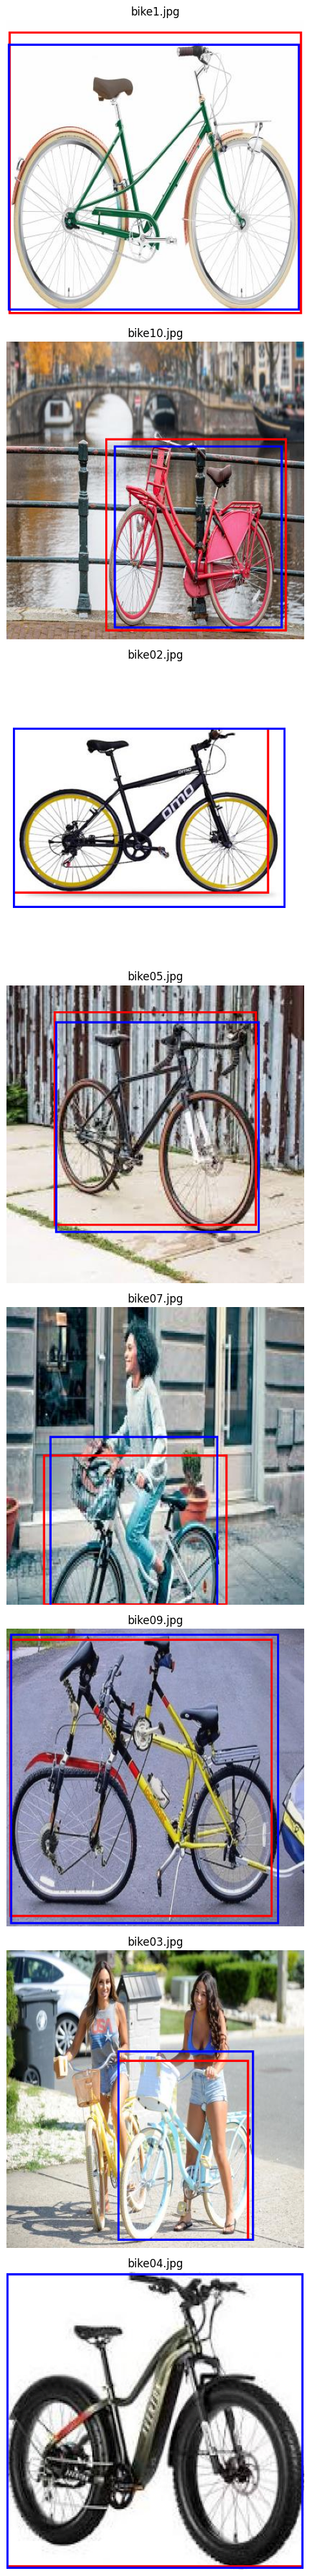

In [30]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw

# Durata de calcul manual: apoximativ 2-3 minute per imagine
# Algoritmul este mult mai rapid si destul de precis(8 secunde pentru toate imaginile)
data = [
    ("bike1.jpg", 2, 33, 407, 372),
    ("bike10.jpg", 150, 145, 235, 255),
    ("bike03.jpg", 155, 140, 190, 265),
    ("bike09.jpg", 5, 7, 375, 405),
    ("bike07.jpg",  60, 180, 235, 240),
    ("bike05.jpg", 68, 50, 285, 295),
    ("bike04.jpg", 0, 2, 414, 412),
    ("bike02.jpg", 9, 90, 380, 251)
]

def detect_bicycle_and_draw_box(image_path):
    with open(image_path, "rb") as image_file:
        analysis = computervision_client.analyze_image_in_stream(image_file, visual_features=["Objects"])

    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)

    bicycle_detected = False
    azure_boxes = []

    for obj in analysis.objects:
        if obj.object_property.lower() in ["bicycle", "bike"]:
            bicycle_detected = True
            x, y, w, h = obj.rectangle.x, obj.rectangle.y, obj.rectangle.w, obj.rectangle.h
            azure_boxes.append((x, y, w, h))
            draw.rectangle([x, y, x + w, y + h], outline="red", width=3)
            print(x, y, x + w, y + h)


    return image, azure_boxes

def process_all_images(folder="bikes_detected"):
    if not os.path.exists(folder):
        print(f"Folderul {folder} nu există!")
        return

    images = os.listdir(folder)
    processed_images = []

    for image_name in images:
        image_path = os.path.join(folder, image_name)
        print(f"Procesăm: {image_name}")
        image, azure_boxes = detect_bicycle_and_draw_box(image_path)

        for img_name, x, y, w, h in data:
            if img_name == image_name:
                draw = ImageDraw.Draw(image)
                draw.rectangle([x, y, x + w, y + h], outline="blue", width=3)
        processed_images.append((image_name, image))

    if processed_images:
        fig, axes = plt.subplots(len(processed_images), 1, figsize=(6, len(processed_images) * 5))
        if len(processed_images) == 1:
            axes = [axes]

        for ax, (name, img) in zip(axes, processed_images):
            ax.imshow(img)
            ax.set_title(name)
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("Nu s-au găsit imagini în folder!")

process_all_images()


In [32]:
import os
import numpy as np
from PIL import Image
from PIL import ImageDraw

def calculate_iou(box1, box2):
    # Zona comuna
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1) # aria comuna

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1]) # arii totale
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union != 0 else 0


def xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]


manual_data = {
    "bike1.jpg": (2, 33, 407, 372),
    "bike10.jpg": (150, 145, 235, 255),
    "bike03.jpg": (155, 140, 190, 265),
    "bike09.jpg": (5, 7, 375, 405),
    "bike07.jpg": (60, 180, 235, 240),
    "bike05.jpg": (68, 50, 285, 295),
    "bike04.jpg": (0, 2, 414, 412),
    "bike02.jpg": (9, 90, 380, 251)
}


def evaluate_performance(folder="bikes_detected"):
    if not os.path.exists(folder):
        print("Folderul nu există.")
        return

    images = os.listdir(folder)
    TP, FP, FN = 0, 0, 0 # detectat corect / detectat degeaba / ratat
    iou_scores = []

    for image_name in images:
        image_path = os.path.join(folder, image_name)

        azure_boxes = []
        with open(image_path, "rb") as image_file:
            analysis = computervision_client.analyze_image_in_stream(
                image_file,
                visual_features=["Objects"]
            )

            for obj in analysis.objects:
                if obj.object_property.lower() in ["bicycle", "bike"]:
                    x, y, w, h = obj.rectangle.x, obj.rectangle.y, obj.rectangle.w, obj.rectangle.h
                    azure_boxes.append((x, y, w, h))

        if image_name in manual_data:
            manual_box_xyxy = xywh_to_xyxy(manual_data[image_name])

            if azure_boxes:
                azure_box_xyxy = xywh_to_xyxy(azure_boxes[0])

                iou = calculate_iou(azure_box_xyxy, manual_box_xyxy)
                iou_scores.append(iou)

                if iou >= 0.5:
                    TP += 1
                else:
                    FN += 1
            else:
                FN += 1
        else:
            if azure_boxes:
                FP += 1

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    mean_iou = np.mean(iou_scores) if iou_scores else 0

    print(f"True positive: {TP}")
    print(f"False positive: {FP}")
    print(f"False negative: {FN}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Mean IoU: {mean_iou:.2f}")

evaluate_performance()

True positive: 8
False positive: 0
False negative: 0
Precision: 1.00
Recall: 1.00
Mean IoU: 0.90
